Before running this file, the processed_data file folder should be eltirely up to date. This is completed by running file_processing_spu.ipynb.


The goal of this file is to identify the location of the peaks in terms of adc channel of each file in processed_data. This ADC information is then printed to a .csv file for purposed of processing in different .ipynb files in this folder.

Because of the complexity of automating the spectrum, each spectrum will be identified manually.

This file:
- computes the background rate
- computes the rate of each target file
- subtracts the background rate from the target file's rate
- takes this adjusted data and creates a graph
- (creates a graph of unadjusted data on top of adjusted data to show effects of the background on data shape; this is unrelated to the propose of the data analysis but is important for the lab writeup)
- asks the user to identify peaks and ranges to fit gaussians to each
- extracts the center for the fitted gaussian as well as error data
- graphs the adjusted data with these fitted gaussians printed on top
- prints all of this extracted information to a .csv
- does this for (almost) every file in processed_data

In [1]:
# -----------------------------
# MATPLOTLIB BACKEND
# -----------------------------

%matplotlib widget

In [2]:
# -----------------------------
# IMPORTS
# -----------------------------

import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
# -----------------------------
# IMPORTS
# -----------------------------

import re
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
# -----------------------------
# FILE LOCATIONS:
# -----------------------------

ROOT = Path("processed_data")

BACKGROUND_FILE = ROOT / "calibration" / "background_550PM_feb26_213PM_mar3.csv"

"""
Not every file in processed_data is relevant for this file.
Everything listed below will be ignored.
"""

irrelevant = [
    "_single_test_converted.csv",
    "calibration/TESTFILE_FOR_CONVERSION_BGND.csv",
    "calibration/background_550PM_feb26_213PM_mar3.csv",
    "cs gain setting/Cs_possible_calcurve_feb_24.csv",
    "cs gain setting/Cs_trial_feb_19.csv",
    "calibration_curves/daily_calibration_params.csv"
]

def normalize_relpath(path, root=ROOT):
    path = Path(path)
    try:
        rel = path.relative_to(root)
    except ValueError:
        rel = path
    return rel.as_posix()

irrelevant_set = set(irrelevant)

print("ROOT:", ROOT)
print("BACKGROUND_FILE:", BACKGROUND_FILE)
print("Background exists:", BACKGROUND_FILE.exists())

ROOT: processed_data
BACKGROUND_FILE: processed_data/calibration/background_550PM_feb26_213PM_mar3.csv
Background exists: True


In [5]:
# -----------------------------
# FIT MODEL
# -----------------------------

def gaussian_with_background(x, A, mu, sigma, m, b):
    """
    Gaussian peak + linear background.
    """
    sigma = abs(sigma)
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + m * x + b

In [6]:
# -----------------------------
# LOAD SPECTRUM / METADATA
# -----------------------------

def _extract_first_number(text):
    """
    Extract the first floating-point number from a string.
    """
    if text is None:
        return None

    match = re.search(r"[-+]?\d*\.?\d+", str(text))
    if match is None:
        return None

    try:
        return float(match.group())
    except ValueError:
        return None


def load_spectrum(csv_path):
    """
    Load a processed spectrum csv with preserved metadata and channel data.

    Expected processed structure:
    - metadata lines near the top
    - a line containing 'Channel Data:'
    - then a data table where:
        column 0 = channel / adc
        column 2 = counts
    """

    csv_path = Path(csv_path)

    with open(csv_path, "r", encoding="utf-8", errors="replace") as f:
        lines = f.readlines()

    metadata = {}
    data_start_idx = None

    for i, line in enumerate(lines):
        stripped = line.strip()

        if stripped == "Channel Data:":
            data_start_idx = i + 1
            break

        if stripped.startswith("Elapsed Real Time:"):
            parts = stripped.split(",", 1)
            metadata["Elapsed Real Time"] = parts[1].strip() if len(parts) > 1 else ""
            continue

        if "Elapsed Real Time:" in stripped:
            value = stripped.split("Elapsed Real Time:", 1)[1]
            value = value.split(",", 1)[1].strip() if "," in value else value.strip()
            metadata["Elapsed Real Time"] = value
            continue

        if stripped.startswith("Start Time:"):
            metadata["Start Time"] = stripped.split("Start Time:", 1)[1].lstrip(",").strip()
            continue

        if stripped.startswith("End Time:"):
            metadata["End Time"] = stripped.split("End Time:", 1)[1].lstrip(",").strip()
            continue

        if "," in stripped:
            left, right = stripped.split(",", 1)
            left = left.strip().rstrip(":")
            right = right.strip()
            if left and right and left not in metadata:
                metadata[left] = right

    if data_start_idx is None:
        raise RuntimeError(f"Could not locate 'Channel Data:' block in {csv_path}")

    # Skip column header if present
    if data_start_idx < len(lines):
        header_line = lines[data_start_idx].strip().lower()
        if header_line.startswith("channel"):
            data_start_idx += 1

    numeric_rows = []

    for line in lines[data_start_idx:]:
        stripped = line.strip()

        if not stripped:
            continue

        parts = [p.strip() for p in stripped.split(",")]

        if len(parts) < 3:
            continue

        try:
            channel = float(parts[0])
            counts = float(parts[2])
            numeric_rows.append((channel, counts))
        except ValueError:
            continue

    if len(numeric_rows) == 0:
        raise RuntimeError(f"No numeric channel/count data found in {csv_path}")

    arr = np.array(numeric_rows, dtype=float)
    x = arr[:, 0]
    counts = arr[:, 1]

    elapsed_real_time = _extract_first_number(metadata.get("Elapsed Real Time"))
    metadata["Elapsed Real Time (s)"] = elapsed_real_time

    return x, counts, metadata


def counts_to_rate(counts, elapsed_time_seconds):
    """
    Convert counts to count rate.
    """
    if elapsed_time_seconds is None or elapsed_time_seconds <= 0:
        raise RuntimeError("Elapsed real time is missing or nonpositive.")
    return counts / elapsed_time_seconds


def compute_background_subtracted_rate(sample_path, background_path=BACKGROUND_FILE):
    """
    Load sample and background spectra, convert both to rates, and subtract
    background rate from sample rate BEFORE any fitting.
    """

    x_sample, counts_sample, meta_sample = load_spectrum(sample_path)
    x_bg, counts_bg, meta_bg = load_spectrum(background_path)

    if len(x_sample) != len(x_bg) or not np.allclose(x_sample, x_bg):
        raise RuntimeError(
            "Sample and background channel grids do not match. "
            "Background subtraction cannot be performed safely."
        )

    t_sample = meta_sample.get("Elapsed Real Time (s)")
    t_bg = meta_bg.get("Elapsed Real Time (s)")

    raw_rate = counts_to_rate(counts_sample, t_sample)
    background_rate = counts_to_rate(counts_bg, t_bg)
    adjusted_rate = raw_rate - background_rate

    return x_sample, raw_rate, background_rate, adjusted_rate, meta_sample, meta_bg

In [7]:
# -----------------------------
# PLOTTING / DIAGNOSTICS
# -----------------------------

def plot_raw_and_adjusted(x, raw_rate, background_rate, adjusted_rate, title="Spectrum"):
    """
    Plot raw rate, background rate, and background-subtracted rate.
    """
    plt.figure()
    plt.plot(x, raw_rate, label="Raw sample rate")
    plt.plot(x, background_rate, label="Background rate")
    plt.plot(x, adjusted_rate, label="Background-subtracted rate")
    plt.xlabel("ADC Channel")
    plt.ylabel("Rate (counts/s)")
    plt.title(title)
    plt.legend()
    plt.show()


def print_metadata_summary(sample_meta, background_meta):
    """
    Print metadata summary so that time normalization is visible.
    """
    print("\nSample metadata:")
    print("  Start Time:", sample_meta.get("Start Time", ""))
    print("  End Time:  ", sample_meta.get("End Time", ""))
    print("  Elapsed Real Time (s):", sample_meta.get("Elapsed Real Time (s)"))

    print("\nBackground metadata:")
    print("  Start Time:", background_meta.get("Start Time", ""))
    print("  End Time:  ", background_meta.get("End Time", ""))
    print("  Elapsed Real Time (s):", background_meta.get("Elapsed Real Time (s)"))

    print("\nMatplotlib backend:", matplotlib.get_backend())

In [8]:
# -----------------------------
# CLICK DEBUG
# -----------------------------

clicked_points = []

def debug_click_plot():
    """
    Minimal diagnostic click plot.
    """
    global clicked_points
    clicked_points = []

    x = np.linspace(0, 10, 500)
    y = np.sin(x)

    fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_title("Debug click plot: click inside axes")

    def onclick(event):
        if event.inaxes is not None:
            clicked_points.append((event.xdata, event.ydata))
            print("Clicked:", clicked_points[-1])

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()

    return fig, ax, cid

In [9]:
# -----------------------------
# CALLBACK-BASED PEAK SELECTION
# -----------------------------

selected_points = []

def start_peak_click_session(x, y, title="Click on peak centers"):
    """
    Start an interactive session for collecting clicked x-locations.
    """
    global selected_points
    selected_points = []

    fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_xlabel("ADC Channel")
    ax.set_ylabel("Background-subtracted rate (counts/s)")
    ax.set_title(title)

    def onclick(event):
        if event.inaxes is not None:
            selected_points.append((float(event.xdata), float(event.ydata)))
            ax.axvline(event.xdata, linestyle="--")
            fig.canvas.draw_idle()
            print(f"Registered click at x = {event.xdata:.3f}")

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()

    return fig, ax, cid

In [10]:
# -----------------------------
# PEAK PARAMETER COLLECTION
# -----------------------------

def build_peak_params_from_clicks():
    """
    Convert clicked points into typed fit windows.
    One click per peak center; fit window is entered manually.
    """
    peak_params = []

    if len(selected_points) == 0:
        print("No clicked peak centers found.")
        return peak_params

    for i, (x0, y0) in enumerate(selected_points, start=1):
        print(f"\nPeak {i}")
        print(f"Clicked center: {x0:.3f}")

        xmin = float(input("Fit range minimum: "))
        xmax = float(input("Fit range maximum: "))

        if xmax < xmin:
            xmin, xmax = xmax, xmin

        peak_params.append((float(x0), xmin, xmax))

    return peak_params


def manual_peak_selection_typed(x, adjusted_rate):
    """
    Fully typed fallback mode.
    """
    plt.figure()
    plt.plot(x, adjusted_rate)
    plt.xlabel("ADC Channel")
    plt.ylabel("Background-subtracted rate (counts/s)")
    plt.title("Background-subtracted gamma spectrum")
    plt.show()

    n_peaks = int(input("Number of peaks to fit: "))

    peak_params = []

    for i in range(n_peaks):
        print(f"\nPeak {i+1}")
        center = float(input("Approximate peak center (ADC): "))
        xmin = float(input("Fit range minimum: "))
        xmax = float(input("Fit range maximum: "))

        if xmax < xmin:
            xmin, xmax = xmax, xmin

        peak_params.append((center, xmin, xmax))

    return peak_params


def manual_peak_selection(x, adjusted_rate):
    """
    Choose between callback-based click collection and typed entry.
    """

    use_clicks = input("Use click-based peak center selection? (y/n): ").strip().lower()

    if use_clicks == "y":
        fig, ax, cid = start_peak_click_session(
            x,
            adjusted_rate,
            title="Click all desired peak centers, then return here"
        )
        input("After clicking all peak centers, press Enter here to continue...")

        peak_params = build_peak_params_from_clicks()

        if len(peak_params) == 0:
            print("No valid click peaks detected; falling back to typed entry.")
            peak_params = manual_peak_selection_typed(x, adjusted_rate)

        return peak_params

    return manual_peak_selection_typed(x, adjusted_rate)

In [11]:
# -----------------------------
# FIT PEAKS
# -----------------------------

def fit_peaks(x, adjusted_rate, peak_params):
    """
    Fit Gaussian + linear background to each user-selected region
    using the background-subtracted rate.
    """

    fit_results = []

    plt.figure()
    plt.plot(x, adjusted_rate, label="Background-subtracted spectrum")

    for center, xmin, xmax in peak_params:

        mask = (x >= xmin) & (x <= xmax)
        xfit = x[mask]
        yfit = adjusted_rate[mask]

        if len(xfit) < 5:
            print(f"Fit skipped near {center}: not enough data points in range [{xmin}, {xmax}]")
            continue

        A0 = float(np.max(yfit) - np.min(yfit))
        if A0 <= 0:
            A0 = float(np.max(np.abs(yfit)))
        if A0 == 0:
            A0 = 1.0

        mu0 = float(center)
        sigma0 = max((xmax - xmin) / 6.0, 1.0)
        m0 = 0.0
        b0 = float(np.median(yfit))

        p0 = [A0, mu0, sigma0, m0, b0]

        try:
            popt, pcov = curve_fit(
                gaussian_with_background,
                xfit,
                yfit,
                p0=p0,
                maxfev=10000
            )

            A, mu, sigma, m, b = popt

            xs = np.linspace(xmin, xmax, 400)
            ys = gaussian_with_background(xs, *popt)

            plt.plot(xs, ys, linewidth=2)

            if pcov is not None:
                perr = np.sqrt(np.diag(pcov))
            else:
                perr = np.full(5, np.nan)

            fit_results.append({
                "center_ADC": float(mu),
                "center_ADC_err": float(perr[1]) if len(perr) > 1 else np.nan,
                "sigma_ADC": float(abs(sigma)),
                "sigma_ADC_err": float(perr[2]) if len(perr) > 2 else np.nan,
                "amplitude_counts_per_s": float(A),
                "background_slope": float(m),
                "background_intercept": float(b),
                "fit_xmin": float(xmin),
                "fit_xmax": float(xmax)
            })

        except Exception as e:
            print(f"Fit failed for peak near {center}: {e}")

    plt.xlabel("ADC Channel")
    plt.ylabel("Background-subtracted rate (counts/s)")
    plt.title("Background-subtracted spectrum with fitted peaks")
    plt.legend()
    plt.show()

    return fit_results

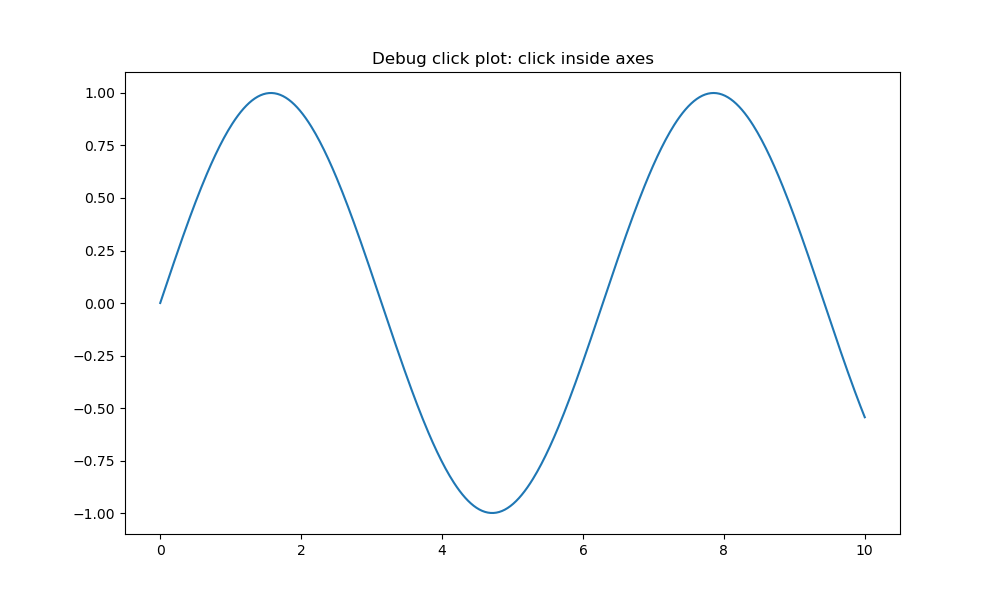

Click on the plot, then inspect `clicked_points` in the next cell.


In [12]:
# -----------------------------
# OPTIONAL CLICK DEBUG RUN
# -----------------------------

# Uncomment these lines only if you want to test whether clicks are being captured.
fig_debug, ax_debug, cid_debug = debug_click_plot()
print("Click on the plot, then inspect `clicked_points` in the next cell.")


------------------------------------
Skipping irrelevant file: _single_test_converted.csv

------------------------------------
Skipping irrelevant file: calibration/TESTFILE_FOR_CONVERSION_BGND.csv

------------------------------------
Skipping irrelevant file: calibration/background_550PM_feb26_213PM_mar3.csv

Processing: calibration/daily/Co60_21.9C_preamp100_mar5.csv


Fit peaks for this spectrum? (y/n):  y



Sample metadata:
  Start Time: Thursday, March 05, 2026, 14:41:28
  End Time:   Thursday, March 05, 2026, 14:56:36
  Elapsed Real Time (s): 908.0

Background metadata:
  Start Time: Thursday, February 26, 2026, 17:44:33
  End Time:   Tuesday, March 03, 2026, 14:07:16
  Elapsed Real Time (s): 418963.0

Matplotlib backend: widget


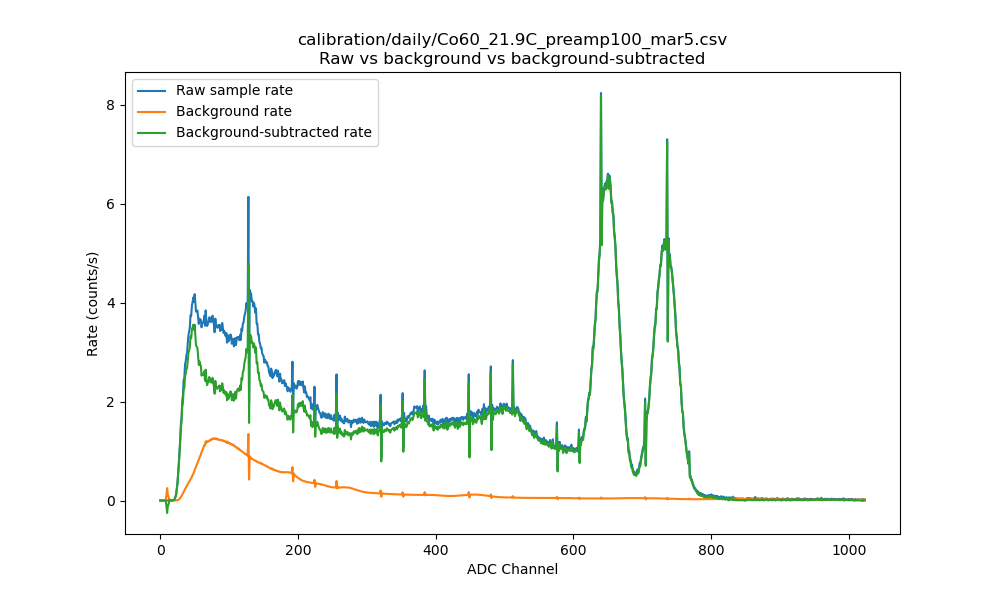

Use click-based peak center selection? (y/n):  y


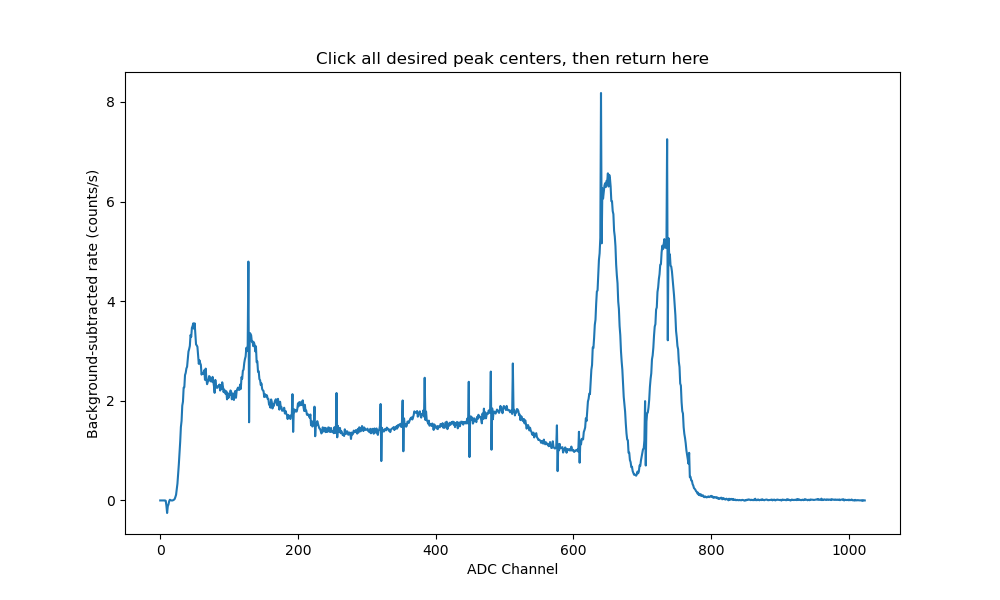

In [ ]:
# -----------------------------
# RUN PEAK ANALYSIS
# -----------------------------

data_dir = ROOT
csv_files = sorted(data_dir.rglob("*.csv"))

results = []

if not BACKGROUND_FILE.exists():
    raise RuntimeError(f"Background file not found: {BACKGROUND_FILE}")

for file in csv_files:

    rel = normalize_relpath(file, data_dir)

    if rel in irrelevant_set:
        print("\n------------------------------------")
        print(f"Skipping irrelevant file: {rel}")
        continue

    print("\n====================================")
    print("Processing:", rel)

    do_fit = input("Fit peaks for this spectrum? (y/n): ").strip().lower()

    if do_fit != "y":
        continue

    try:
        x, raw_rate, background_rate, adjusted_rate, sample_meta, background_meta = compute_background_subtracted_rate(
            file,
            background_path=BACKGROUND_FILE
        )
    except Exception as e:
        print(f"Could not process {rel}: {e}")
        continue

    print_metadata_summary(sample_meta, background_meta)

    plot_raw_and_adjusted(
        x,
        raw_rate,
        background_rate,
        adjusted_rate,
        title=f"{rel}\nRaw vs background vs background-subtracted"
    )

    peak_params = manual_peak_selection(x, adjusted_rate)
    fits = fit_peaks(x, adjusted_rate, peak_params)

    for fit in fits:
        fit["file"] = rel
        fit["sample_elapsed_real_time_s"] = sample_meta.get("Elapsed Real Time (s)")
        fit["background_elapsed_real_time_s"] = background_meta.get("Elapsed Real Time (s)")
        fit["sample_start_time"] = sample_meta.get("Start Time", "")
        fit["sample_end_time"] = sample_meta.get("End Time", "")
        results.append(fit)

In [3]:
# -----------------------------
# SAVE RESULTS
# -----------------------------

results_df = pd.DataFrame(results)

out_dir = Path("peak_analysis_outputs")
out_dir.mkdir(exist_ok=True)

out_file = out_dir / "manual_peak_fits.csv"

results_df.to_csv(out_file, index=False)

print("\nSaved peak fits to:", out_file)
results_df.head()